# Fine-tuning strategies for a foundation model: naive, LoRA and multi-head replay

The MACE fine-tuning protocols (Batatia *et al.*, arXiv:2401.00096; Tompa *et al.*,
arXiv:2606.12704; Wang *et al.*, ELoRA, ICML 2025) are available for every xnn model
through the training config and `xnn.common.finetune`. This notebook runs them side by
side on the **MACE-OFF23 small** foundation model and a small target set, the setting of
Table 1 of the ELoRA paper (rMD17, 50 training structures per molecule):

1. **reference energies**: the model-aware reestimation (Tompa eq. 6) against plain
   averaging (eq. 5) before any training;
2. **four strategies** with the hyperparameters of Tompa *et al.* (Table 7): naive
   fine-tuning, readout-only (frozen trunk), LoRA (rank 16), and multi-head
   pseudolabel replay;
3. **target accuracy and forgetting**: energy and force errors on the rMD17 ethanol test
   set, and the drift of each fine-tuned model away from the foundation model on
   molecules it never saw during fine-tuning;
4. **deployment**: a multi-head checkpoint served one head at a time, a LoRA checkpoint
   with the updates folded in, TorchScript export.

MACE-OFF23 is distributed under the Academic Software License (no commercial use).

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")
import contextlib
import copy
import io
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
rng = np.random.default_rng(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float32)

import xnn
from xnn.common.config import from_dict
from xnn.common.data import AtomicDataset, collate, load_dataset, structure_to_graph
from xnn.common.finetune import (MultiHead, average_atomic_energies, count_parameters,
                                 estimate_atomic_energies, get_atomic_energies,
                                 has_lora, merge_lora, set_atomic_energies)
from xnn.common.models import ForceStressOutput, from_pretrained
from xnn.common.train import Trainer

print("xnn:", xnn.__version__, "| device:", DEVICE)

xnn: 0.6.0 | device: cuda


## 1. The foundation model and the data

`from_pretrained` gives the pretrained potential (converted once from `mace-torch` and
cached); the config entry `pretrained: mace-off23-small` builds the same model inside the
trainer. The target is rMD17 **ethanol** at the PBE/def2-SVP level, a different functional
from the wB97M-D3(BJ) labels of MACE-OFF23: 50 training, 50 validation and 500 test
structures. Three other rMD17 molecules (aspirin, toluene, uracil) probe how far each
fine-tuned model drifts from the foundation model where no target data exists, and four
more supply the structures of the pseudolabelled replay set.

In [2]:
with contextlib.redirect_stdout(io.StringIO()):
    foundation = from_pretrained("mace-off23-small", dtype=torch.float32, device=DEVICE)
CUTOFF = float(foundation.model.cutoff)
print(f"MACE-OFF23 small: {count_parameters(foundation):,} parameters, cutoff {CUTOFF} A, "
      f"species {foundation.model.species}")

N_TRAIN, N_VAL, N_TEST, N_PROBE, N_REPLAY = 50, 50, 500, 100, 400
eth_train_all = load_dataset("rmd17", molecule="ethanol", split="train", quiet=True)
eth_test_all = load_dataset("rmd17", molecule="ethanol", split="test", quiet=True)
train_structs = eth_train_all[:N_TRAIN]
val_structs = eth_train_all[N_TRAIN:N_TRAIN + N_VAL]
test_structs = eth_test_all[:N_TEST]
probes = {m: load_dataset("rmd17", molecule=m, split="test", quiet=True)[:N_PROBE]
          for m in ("aspirin", "toluene", "uracil")}
replay_pool = []
for m in ("benzene", "malonaldehyde", "naphthalene", "salicylic"):
    replay_pool += load_dataset("rmd17", molecule=m, split="train", quiet=True)[:N_REPLAY // 4]
print(f"ethanol: {len(train_structs)} train / {len(val_structs)} val / {len(test_structs)} test; "
      f"probes: {sum(map(len, probes.values()))} structures; replay pool: {len(replay_pool)}")

mace-off23-small is distributed under the Academic Software License (https://github.com/gabor1/ASL); by using it you accept its terms (no commercial use).


MACE-OFF23 small: 694,520 parameters, cutoff 4.5 A, species [1, 6, 7, 8, 9, 15, 16, 17, 35, 53]


ethanol: 50 train / 50 val / 500 test; probes: 300 structures; replay pool: 400


In [3]:
def predict(fmodel, structs, batch_size=50):
    """Energies (eV) and forces (eV/A) of ``fmodel`` on structure dicts."""
    fmodel.eval()
    es, fs = [], []
    for i0 in range(0, len(structs), batch_size):
        batch = collate([structure_to_graph(s, CUTOFF) for s in structs[i0:i0 + batch_size]]).to(DEVICE)
        out = fmodel(batch)
        es.append(out["energy"].detach().cpu())
        fs.append(out["forces"].detach().cpu())
    return torch.cat(es), torch.cat(fs)


def errors(fmodel, structs):
    """Energy MAE (meV/atom) and force MAE (meV/A) against the rMD17 labels."""
    e, f = predict(fmodel, structs)
    e_ref = torch.tensor([s["energy"] for s in structs], dtype=e.dtype)
    f_ref = torch.cat([torch.as_tensor(s["forces"], dtype=f.dtype) for s in structs])
    n = torch.tensor([len(s["atomic_numbers"]) for s in structs], dtype=e.dtype)
    return float(((e - e_ref) / n).abs().mean() * 1000), float((f - f_ref).abs().mean() * 1000)


foundation_forces = {m: predict(foundation, s)[1] for m, s in probes.items()}


def drift(fmodel):
    """Force RMSE (meV/A) between ``fmodel`` and the foundation model on the probe molecules."""
    d = [((predict(fmodel, s)[1] - foundation_forces[m]) ** 2).mean() for m, s in probes.items()]
    return float(torch.stack(d).mean().sqrt() * 1000)


e_mae0, f_mae0 = errors(foundation, test_structs)
print(f"zero-shot, foundation E0s: energy MAE {e_mae0:.0f} meV/atom (reference-energy offset), "
      f"force MAE {f_mae0:.1f} meV/A")

zero-shot, foundation E0s: energy MAE 1259 meV/atom (reference-energy offset), force MAE 369.9 meV/A


## 2. Reference energies before training

The two levels of theory differ by composition-dependent constants, so the per-element
reference energies must be re-set before the fit. Averaging (Tompa eq. 5) fits the training
energies to the compositions alone and absorbs the mean interaction energy into the
references; the model-aware reestimation (eq. 6) fits only the residual between the
pretrained predictions and the new labels, so the foundation model's interaction energies
survive. Ethanol has one composition, so both systems are degenerate and the minimum-norm
solution is taken; the per-element values differ in how the shift is spread, and the
zero-shot energy error shows which one keeps the model intact.

In [4]:
e0_found = get_atomic_energies(foundation.model)
e0_avg = average_atomic_energies(train_structs)
e0_est = estimate_atomic_energies(foundation, train_structs, device=DEVICE)
print(f"{'Z':>3} {'foundation':>12} {'averaged':>12} {'reestimated':>12}")
for z in sorted(e0_est):
    print(f"{z:>3} {e0_found[z]:>12.3f} {e0_avg[z]:>12.3f} {e0_est[z]:>12.3f}")

zero_shot = {}
for label, e0 in (("averaged E0s", e0_avg), ("reestimated E0s", e0_est)):
    probe_model = copy.deepcopy(foundation)
    set_atomic_energies(probe_model.model, e0)
    zero_shot[label] = errors(probe_model, test_structs)
    print(f"zero-shot with {label}: energy MAE {zero_shot[label][0]:.1f} meV/atom, "
          f"force MAE {zero_shot[label][1]:.1f} meV/A")
assert zero_shot["reestimated E0s"][0] < 0.5 * zero_shot["averaged E0s"][0]

  Z   foundation     averaged  reestimated
  1      -13.572     -616.038      -11.915
  6    -1030.567     -205.346    -1030.015
  8    -2043.934     -102.673    -2043.658


zero-shot with averaged E0s: energy MAE 3824.7 meV/atom, force MAE 369.9 meV/A


zero-shot with reestimated E0s: energy MAE 7.1 meV/atom, force MAE 369.9 meV/A


## 3. Four fine-tuning strategies

All runs share the data, the constant target loss weights (energy 10, force 10, as
recommended by Tompa *et al.* over two-stage schedules), AdamW without weight decay,
an exponential moving average of the weights and gradient clipping; the learning rate,
EMA decay and clipping follow their Table 7 per method. The reference energies of the
target head are reestimated by the trainer (`atomic_energies: estimated`). The multi-head
run keeps the pretrained readout as `pt_head`, trained on 400 structures of four other
molecules **pseudolabelled by the foundation model itself** (energy weight 1, force weight
10, the pretraining weighting), while the copy `Default` adapts to ethanol.

In [5]:
EPOCHS, BATCH = 200, 5
train_set = AtomicDataset(copy.deepcopy(train_structs), CUTOFF)
val_set = AtomicDataset(copy.deepcopy(val_structs), CUTOFF)

COMMON = {"data": {"batch_size": BATCH, "val_fraction": 0.0},
          "optim": {"epochs": EPOCHS, "energy_weight": 10.0, "force_weight": 10.0,
                    "weight_decay": 0.0, "optimizer": "adamw", "scheduler": "plateau"},
          "device": DEVICE, "seed": 0}
MODEL = {"name": "mace", "pretrained": "mace-off23-small", "cutoff": CUTOFF, "dtype": "float32"}

STRATEGIES = {
    "naive": dict(model={**MODEL, "atomic_energies": "estimated"},
                  optim={"lr": 1e-3, "ema_decay": 0.999, "clip_grad": 1.0}),
    "readout only": dict(model={**MODEL, "atomic_energies": "estimated"},
                         optim={"lr": 1e-3, "ema_decay": 0.999, "clip_grad": 1.0,
                                "train_only": ["*readouts*", "*atom_ref*"]}),
    "LoRA (r=16)": dict(model={**MODEL, "atomic_energies": "estimated", "lora": {"rank": 16}},
                        optim={"lr": 1e-2, "ema_decay": 0.99, "clip_grad": 10.0}),
    "multi-head replay": dict(model={**MODEL, "heads": {"pt_head": None,
                                                        "Default": {"atomic_energies": "estimated"}}},
                              optim={"lr": 1e-4, "ema_decay": 0.9999, "clip_grad": 1.0,
                                     "head_weights": {"pt_head": {"energy_weight": 1.0,
                                                                  "force_weight": 10.0}}},
                              data={"replay_pseudolabel": True}),
}

results, logs, trainers = {}, {}, {}
for name, spec in STRATEGIES.items():
    cfg = from_dict({"model": spec["model"],
                     "data": {**COMMON["data"], **spec.get("data", {})},
                     "optim": {**COMMON["optim"], **spec["optim"]},
                     "device": DEVICE, "seed": 0,
                     "output_dir": f"runs/finetune_{name.split()[0].lower()}"})
    replay = (AtomicDataset(copy.deepcopy(replay_pool), CUTOFF)
              if "heads" in spec["model"] else None)
    torch.manual_seed(0)
    log = io.StringIO()
    t0 = time.time()
    with contextlib.redirect_stdout(log):
        trainer = Trainer(cfg, AtomicDataset(copy.deepcopy(train_structs), CUTOFF),
                          AtomicDataset(copy.deepcopy(val_structs), CUTOFF), replay_set=replay)
        trainer.fit()
    wall = time.time() - t0
    model = trainer.eval_module
    n_train = count_parameters(trainer.module, trainable_only=True)
    if trainer.heads:
        multi = trainer.module.model
        target = ForceStressOutput(multi.select("Default")).to(DEVICE)
        pt = ForceStressOutput(multi.select("pt_head")).to(DEVICE)
        e_mae, f_mae = errors(target, test_structs)
        drift_target, drift_pt = drift(target), drift(pt)
    else:
        e_mae, f_mae = errors(model, test_structs)
        drift_target, drift_pt = drift(model), None
    results[name] = dict(energy_mae=e_mae, force_mae=f_mae, drift=drift_target, drift_pt=drift_pt,
                         trainable=n_train, wall=wall)
    logs[name], trainers[name] = log.getvalue(), trainer
    print(f"{name:>18}: energy MAE {e_mae:5.1f} meV/atom | force MAE {f_mae:5.1f} meV/A | "
          f"drift {drift_target:5.1f} meV/A"
          + (f" (pt_head {drift_pt:.1f})" if drift_pt is not None else "")
          + f" | {n_train:,} trainable | {wall / 60:.1f} min")

             naive: energy MAE   2.2 meV/atom | force MAE  50.2 meV/A | drift 244.9 meV/A | 694,520 trainable | 2.2 min


      readout only: energy MAE   7.4 meV/atom | force MAE  88.0 meV/A | drift 214.8 meV/A | 1,848 trainable | 1.8 min


       LoRA (r=16): energy MAE   0.5 meV/atom | force MAE  17.0 meV/A | drift 262.9 meV/A | 67,008 trainable | 2.2 min


 multi-head replay: energy MAE   0.6 meV/atom | force MAE  17.4 meV/A | drift 127.6 meV/A (pt_head 70.8) | 696,368 trainable | 17.5 min


### Results

Target accuracy on the 500 ethanol test structures, drift from the foundation model on
aspirin, toluene and uracil (force RMSE between the fine-tuned and the foundation
predictions), and the trainable fraction of the model.

In [6]:
zs_e, zs_f = zero_shot["reestimated E0s"]
n_total = count_parameters(foundation)
print(f"{'strategy':>18} {'E MAE':>8} {'F MAE':>8} {'drift':>8} {'trainable':>10}")
print(f"{'(meV/atom, meV/A)':>18} {'':>8} {'':>8} {'':>8} {'':>10}")
print(f"{'zero-shot':>18} {zs_e:8.1f} {zs_f:8.1f} {0.0:8.1f} {'0.0%':>10}")
for name, r in results.items():
    print(f"{name:>18} {r['energy_mae']:8.1f} {r['force_mae']:8.1f} {r['drift']:8.1f} "
          f"{100 * r['trainable'] / n_total:9.1f}%")

# every strategy improves on the zero-shot model; the replay head stays closest to the
# foundation model away from the target data
assert all(r["force_mae"] < 0.5 * zs_f for r in results.values())
assert results["multi-head replay"]["drift_pt"] < results["naive"]["drift"]

          strategy    E MAE    F MAE    drift  trainable
 (meV/atom, meV/A)                                      
         zero-shot      7.1    369.9      0.0       0.0%
             naive      2.2     50.2    244.9     100.0%
      readout only      7.4     88.0    214.8       0.3%
       LoRA (r=16)      0.5     17.0    262.9       9.6%
 multi-head replay      0.6     17.4    127.6     100.3%


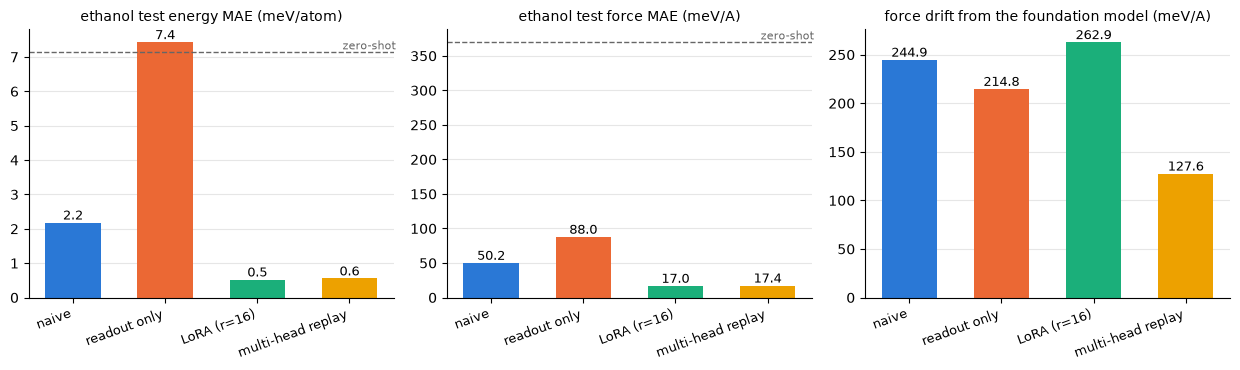

In [7]:
names = list(results)
colors = {"naive": "#2a78d6", "readout only": "#eb6834", "LoRA (r=16)": "#1baf7a",
          "multi-head replay": "#eda100"}
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.8))
panels = [("energy_mae", "ethanol test energy MAE (meV/atom)"),
          ("force_mae", "ethanol test force MAE (meV/A)"),
          ("drift", "force drift from the foundation model (meV/A)")]
for a, (key, title) in zip(ax, panels):
    vals = [results[n][key] for n in names]
    bars = a.bar(range(len(names)), vals, color=[colors[n] for n in names], width=0.6)
    for b, v in zip(bars, vals):
        a.text(b.get_x() + b.get_width() / 2, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
    ref = {"energy_mae": zs_e, "force_mae": zs_f}.get(key)
    if ref is not None:
        a.axhline(ref, color="0.4", lw=1, ls="--")
        a.text(len(names) - 0.5, ref, "zero-shot", ha="right", va="bottom", fontsize=8, color="0.4")
    a.set_xticks(range(len(names)))
    a.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
    a.set_title(title, fontsize=10)
    a.spines[["top", "right"]].set_visible(False)
    a.grid(axis="y", color="0.9", lw=0.8)
    a.set_axisbelow(True)
fig.tight_layout()
fig.savefig("mace_finetuning_strategies.png", dpi=150)
plt.show()

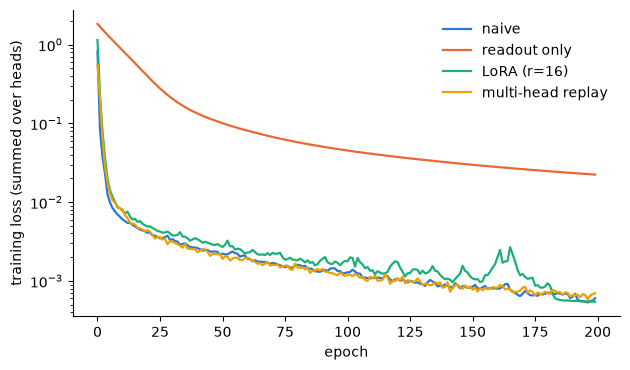

In [8]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
for name in names:
    losses = [float(line.split("train loss")[1].split("|")[0])
              for line in logs[name].splitlines() if "train loss" in line]
    ax.semilogy(losses, color=colors[name], lw=1.6, label=name)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss (summed over heads)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## 4. Deployment

A fine-tuned checkpoint is served like any other xnn model. The multi-head checkpoint
keeps both heads; `from_pretrained(..., head=...)` (or `xnn export --head`, `xnn mdi
--head`) returns the plain single-head potential. The LoRA checkpoint keeps its adapters,
and loading it folds the updates into the base weights, so the served model has the
original architecture and inference cost. Both export to TorchScript as usual.

In [9]:
from xnn.common.deploy import export_torchscript_potential

mh_dir = trainers["multi-head replay"].save_pretrained("runs/finetune_multi/model",
                                                     description="MACE-OFF23 small, multi-head replay fine-tune on rMD17 ethanol")
served = from_pretrained(mh_dir, head="Default", device=DEVICE)
reference = ForceStressOutput(trainers["multi-head replay"].eval_module.model.select("Default")).to(DEVICE)
e_served, _ = predict(served, test_structs[:20])
e_ref, _ = predict(reference, test_structs[:20])
print(f"multi-head directory served as 'Default': max |dE| = {(e_served - e_ref).abs().max():.2e} eV")

lora_ckpt = "runs/finetune_lora/last.pt"
served_lora = from_pretrained(lora_ckpt, device=DEVICE)
merged = merge_lora(copy.deepcopy(trainers["LoRA (r=16)"].eval_module)).to(DEVICE)
e_served, _ = predict(served_lora, test_structs[:20])
e_ref, _ = predict(merged, test_structs[:20])
print(f"LoRA checkpoint served with the updates folded in: has_lora={has_lora(served_lora)}, "
      f"max |dE| = {(e_served - e_ref).abs().max():.2e} eV")

path = export_torchscript_potential(served_lora.model.cpu(), CUTOFF, "runs/finetune_lora/deployed.pt",
                                    {"model": "mace", "species": foundation.model.species})
print("TorchScript artifact:", path)

multi-head directory served as 'Default': max |dE| = 1.91e-06 eV


LoRA checkpoint served with the updates folded in: has_lora=False, max |dE| = 1.91e-06 eV


TorchScript artifact: runs/finetune_lora/deployed.pt


## Summary

* **Reference energies first.** With one composition the averaged references absorb the
  foundation model's interaction energy and leave a large zero-shot error; the model-aware
  reestimation keeps the pretrained interaction energies and is what every run below starts
  from (Tompa *et al.*, Sec. 3.2).
* **All strategies beat the zero-shot model** on ethanol with 50 structures. LoRA (rank
  16, under 10% of the parameters trainable, a ten times larger learning rate) and the
  target head of the multi-head run reach the lowest errors, about 0.5 meV/atom and
  17 meV/A; naive fine-tuning at the prescribed learning rate lands at 2.2 meV/atom and
  50 meV/A, readout-only at 7.4 and 88. The ordering LoRA ahead of full-parameter
  fine-tuning at 50 structures is the one Table 1 of the ELoRA paper reports for rMD17
  (ethanol: 2.1 vs 2.7 meV, 10.7 vs 13.9 meV/A with the larger MACE-OFF model and its
  longer schedule).
* **Multi-head replay preserves the foundation model.** Its pretraining head drifts least
  from MACE-OFF23 on molecules absent from the fine-tuning set (about 70 meV/A against
  240 to 260 for naive fine-tuning and LoRA), the behaviour Tompa *et al.* report for
  replay-based methods, at the price of about eight times the training compute.
* The same config keys (`pretrained`, `lora`, `heads`, `atomic_energies: estimated`,
  `data.replay_path`) apply to every xnn model with a readout head, and the trained
  checkpoints deploy through `from_pretrained`, `xnn export` and `xnn mdi`.